# Random Forest Classification

This notebook builds a Random Forest model to predict the **Category** of a product purchase based on user demographics, purchase features, and temporal features.

**Key challenges:**
- 1,625 unique product categories (highly multi-class)
- Many rare categories (1,048 with < 50 samples)
- ~157K rows, 184 features
- Temporal train/test split (train ≤ 2021, test > 2021)

**Outline:**
1. Data loading and preparation
2. Baseline Random Forest
3. Feature importance analysis
4. Hyperparameter tuning
5. Final evaluation (precision, recall, F1)
6. Cross-validation

## 1. Data Loading and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, make_scorer
)
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Scorer with zero_division=0 prevents NaN when folds contain unseen classes
scorer = make_scorer(f1_score, average='weighted', zero_division=0)

print('Libraries loaded.')

Libraries loaded.


In [2]:
data = pd.read_csv('../data/cleaned_data.csv')
print(f'Dataset shape: {data.shape}')
print(f'Unique categories: {data["Category"].nunique()}')
data.head()

Dataset shape: (157026, 156)
Unique categories: 1625


,Purchase Price Per Unit,Quantity,Title,ASIN/ISBN (Product Code),Category,age,hispanic,education,income,howmany,...,"life-changes_Lost a job ,Divorce","life-changes_Lost a job ,Divorce,Moved place of residence","life-changes_Lost a job ,Had a child","life-changes_Lost a job ,Moved place of residence","life-changes_Lost a job ,Moved place of residence,Became pregnant","life-changes_Lost a job ,Moved place of residence,Became pregnant,Had a child","life-changes_Lost a job ,Moved place of residence,Had a child",life-changes_Moved place of residence,"life-changes_Moved place of residence,Became pregnant,Had a child","life-changes_Moved place of residence,Had a child"
0,7.98,1,83780,34099,586,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,13.99,1,16614,43470,729,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10.45,1,73826,47343,432,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10.00,1,77034,21023,1240,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10.99,1,62681,39476,331,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Temporal train/test split
train = data[data['order_year'] <= 2021].copy()
test = data[data['order_year'] > 2021].copy()

print(f'Train size: {len(train):,} | Test size: {len(test):,}')
print(f'Train categories: {train["Category"].nunique()} | Test categories: {test["Category"].nunique()}')

# Check for categories in test that don't appear in training
train_cats = set(train['Category'].unique())
test_cats = set(test['Category'].unique())
unseen = test_cats - train_cats
print(f'Categories in test but not in train: {len(unseen)}')

Train size: 113,655 | Test size: 43,371
Train categories: 1601 | Test categories: 1458
Categories in test but not in train: 24


In [4]:
# Remove test samples with categories unseen during training
if len(unseen) > 0:
    test = test[~test['Category'].isin(unseen)]
    print(f'Removed {len(unseen)} unseen categories from test set.')
    print(f'Adjusted test size: {len(test):,}')

Removed 24 unseen categories from test set.
Adjusted test size: 43,329


In [5]:
# Drop non-predictive columns
drop_cols = ['Title', 'ASIN/ISBN (Product Code)']

X_train = train.drop(['Category'] + drop_cols, axis=1)
y_train = train['Category']

X_test = test.drop(['Category'] + drop_cols, axis=1)
y_test = test['Category']

print(f'Features: {X_train.shape[1]}')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

Features: 153
X_train: (113655, 153) | X_test: (43329, 153)


In [6]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use same scaler as training

print('Features scaled.')

Features scaled.


In [7]:
# Use full training set — 32GB RAM handles 157K × 156 comfortably
X_train_sub = X_train_scaled
y_train_sub = y_train

print(f'Training size: {len(X_train_sub):,}')

Training size: 113,655


## 2. Baseline Random Forest

We first train on the full dataset. If this is too slow, a subsampled fallback is provided below.

In [8]:
%%time

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

rf_baseline.fit(X_train_sub, y_train_sub)
print('Baseline model trained.')

Baseline model trained.
CPU times: total: 5min 10s
Wall time: 12.3 s


In [9]:
# Baseline predictions and metrics
y_pred_baseline = rf_baseline.predict(X_test_scaled)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1_macro = f1_score(y_test, y_pred_baseline, average='macro', zero_division=0)
baseline_f1_weighted = f1_score(y_test, y_pred_baseline, average='weighted', zero_division=0)

print(f'Baseline Accuracy:         {baseline_acc:.4f}')
print(f'Baseline F1 (macro):       {baseline_f1_macro:.4f}')
print(f'Baseline F1 (weighted):    {baseline_f1_weighted:.4f}')

Baseline Accuracy:         0.0278
Baseline F1 (macro):       0.0116
Baseline F1 (weighted):    0.0318


In [10]:
# Full-data training is used throughout. No subsample fallback needed.

## 3. Feature Importance Analysis

In [11]:
# Feature importances from baseline model
feature_names = X_train.columns
importances = rf_baseline.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Top 20 most important features:')
feat_imp.head(20)

Top 20 most important features:


,Feature,Importance
0,Purchase Price Per Unit,0.254917
10,order_day,0.202385
9,order_month,0.166469
11,order_year,0.094087
1,Quantity,0.018035
5,income,0.015893
2,age,0.015189
7,hh-size,0.012725
4,education,0.012475
8,how-oft,0.011121


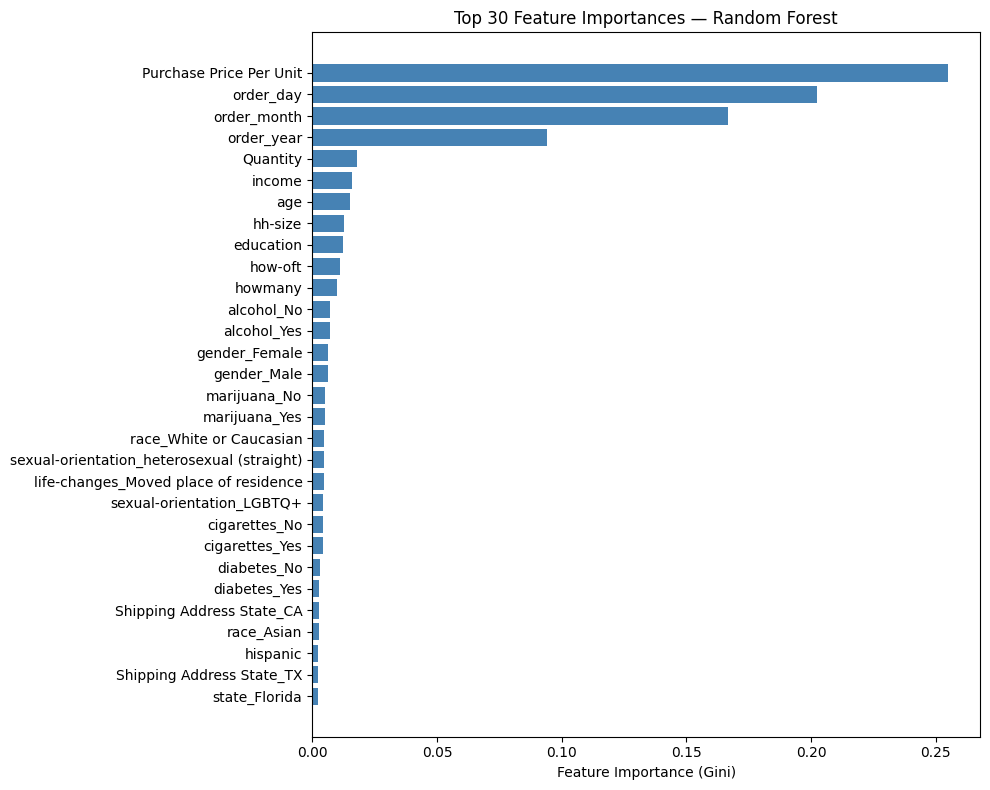

In [12]:
# Plot top 30 features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 30
top_feats = feat_imp.head(top_n)

ax.barh(range(top_n), top_feats['Importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Top 30 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

Features needed for 90% importance: 33 / 153
Features needed for 95% importance: 62 / 153


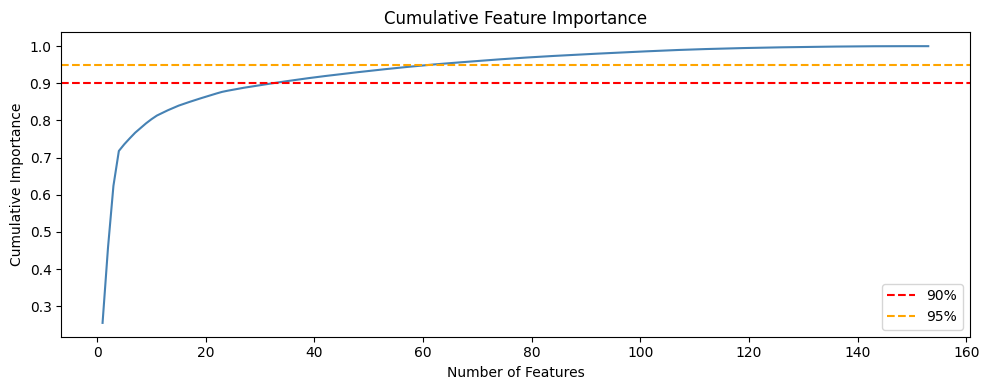

In [13]:
# Cumulative importance
feat_imp['Cumulative'] = feat_imp['Importance'].cumsum()

n_90 = (feat_imp['Cumulative'] <= 0.90).sum() + 1
n_95 = (feat_imp['Cumulative'] <= 0.95).sum() + 1

print(f'Features needed for 90% importance: {n_90} / {len(feature_names)}')
print(f'Features needed for 95% importance: {n_95} / {len(feature_names)}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(feat_imp) + 1), feat_imp['Cumulative'].values, color='steelblue')
ax.axhline(y=0.90, color='r', linestyle='--', label='90%')
ax.axhline(y=0.95, color='orange', linestyle='--', label='95%')
ax.set_xlabel('Number of Features')
ax.set_ylabel('Cumulative Importance')
ax.set_title('Cumulative Feature Importance')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning

`RandomizedSearchCV` on a 30K subsample to find good hyperparameters without exhausting RAM across 45 sequential CV fits. The final model (Section 5) is then retrained on the full 113K dataset with the best params.

In [14]:
%%time

# Use a subsample for HP search — 45 sequential CV fits on full data exhaust RAM.
# Best params are then used to retrain on the full 113K set.
SEARCH_SIZE = 30_000
np.random.seed(42)
search_idx = np.random.choice(len(X_train_sub), size=SEARCH_SIZE, replace=False)
X_search = X_train_sub[search_idx]
y_search = y_train_sub.iloc[search_idx]

# max_depth=None/50 and max_features=None excluded: with 1,625 classes, each
# tree node stores a 13KB probability vector — unconstrained trees exhaust RAM
# on the full 113K dataset even though they fit fine on the 30K search sample.
param_distributions = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf_search = RandomForestClassifier(n_jobs=-1, random_state=42)

random_search = RandomizedSearchCV(
    rf_search,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring=scorer,
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(X_search, y_search)

print(f'\nBest score (F1 weighted): {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best score (F1 weighted): 0.0907
Best parameters: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': None}
CPU times: total: 10min 26s
Wall time: 1min 41s


In [15]:
# View all search results
search_results = pd.DataFrame(random_search.cv_results_)
search_results = search_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
search_results.sort_values('rank_test_score').head(10)

,params,mean_test_score,std_test_score,rank_test_score
5,"{'n_estimators': 50, 'min_samples_split': 10, ...",0.090674,0.002005,1
3,"{'n_estimators': 100, 'min_samples_split': 10,...",0.088814,0.002585,2
14,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.086522,0.001687,3
12,"{'n_estimators': 50, 'min_samples_split': 5, '...",0.075853,0.000668,4
0,"{'n_estimators': 50, 'min_samples_split': 10, ...",0.072179,0.002689,5
2,"{'n_estimators': 200, 'min_samples_split': 10,...",0.064515,0.001591,6
13,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.047590,0.001937,7
4,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.039883,0.001575,8
7,"{'n_estimators': 50, 'min_samples_split': 2, '...",0.036146,0.002356,9
9,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.033007,0.000865,10


## 5. Tuned Model — Full Training and Evaluation

In [16]:
%%time

# With 1,625 classes, max_features=None and max_depth>30 cause OOM on 113K rows
# (each node stores a 13KB class-probability vector). Cap before full-data fit.
safe_params = dict(random_search.best_params_)
if safe_params.get('max_features') is None:
    safe_params['max_features'] = 'sqrt'
if safe_params.get('max_depth') is None or safe_params.get('max_depth', 0) > 30:
    safe_params['max_depth'] = 30
best_params = safe_params

print(f'Training tuned model with: {best_params}')

rf_tuned = RandomForestClassifier(
    **best_params,
    n_jobs=-1,
    random_state=42
)

rf_tuned.fit(X_train_sub, y_train_sub)
print('Tuned model trained.')

Training tuned model with: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': None}
Tuned model trained.
CPU times: total: 1min 18s
Wall time: 4.41 s


In [17]:
# Tuned model predictions and metrics
y_pred_tuned = rf_tuned.predict(X_test_scaled)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec_macro = precision_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_rec_macro = recall_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_f1_macro = f1_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_f1_weighted = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)

print('=== Tuned Random Forest Results ===')
print(f'Accuracy:             {tuned_acc:.4f}')
print(f'Precision (macro):    {tuned_prec_macro:.4f}')
print(f'Recall (macro):       {tuned_rec_macro:.4f}')
print(f'F1 Score (macro):     {tuned_f1_macro:.4f}')
print(f'F1 Score (weighted):  {tuned_f1_weighted:.4f}')

print(f'\n--- Comparison ---')
print(f'Baseline accuracy:    {baseline_acc:.4f}')
print(f'Tuned accuracy:       {tuned_acc:.4f}')
print(f'Improvement:          {tuned_acc - baseline_acc:+.4f}')

=== Tuned Random Forest Results ===
Accuracy:             0.0728
Precision (macro):    0.0157
Recall (macro):       0.0138
F1 Score (macro):     0.0126
F1 Score (weighted):  0.0536

--- Comparison ---
Baseline accuracy:    0.0278
Tuned accuracy:       0.0728
Improvement:          +0.0450


In [18]:
# Per-class classification report (top 20 most frequent categories)
top_20_cats = y_test.value_counts().head(20).index.tolist()
mask = y_test.isin(top_20_cats)

print('Classification Report — Top 20 Most Frequent Categories:')
print(classification_report(
    y_test[mask], y_pred_tuned[mask],
    labels=top_20_cats,
    zero_division=0
))

Classification Report — Top 20 Most Frequent Categories:
              precision    recall  f1-score   support

           2       0.43      0.45      0.44      1715
        1044       0.51      0.36      0.42       864
        1248       0.28      0.11      0.16       823
         983       0.42      0.23      0.29       694
         906       0.36      0.14      0.20       491
        1015       0.16      0.06      0.08       423
         499       0.31      0.14      0.20       421
        1276       0.28      0.08      0.12       419
         731       0.20      0.06      0.09       371
        1251       0.37      0.11      0.17       370
        1271       0.39      0.15      0.21       358
         278       0.11      0.04      0.06       320
        1465       0.42      0.13      0.20       305
         595       0.50      0.07      0.12       289
        1560       0.29      0.08      0.13       285
        1050       0.17      0.05      0.08       275
         300       0.08 

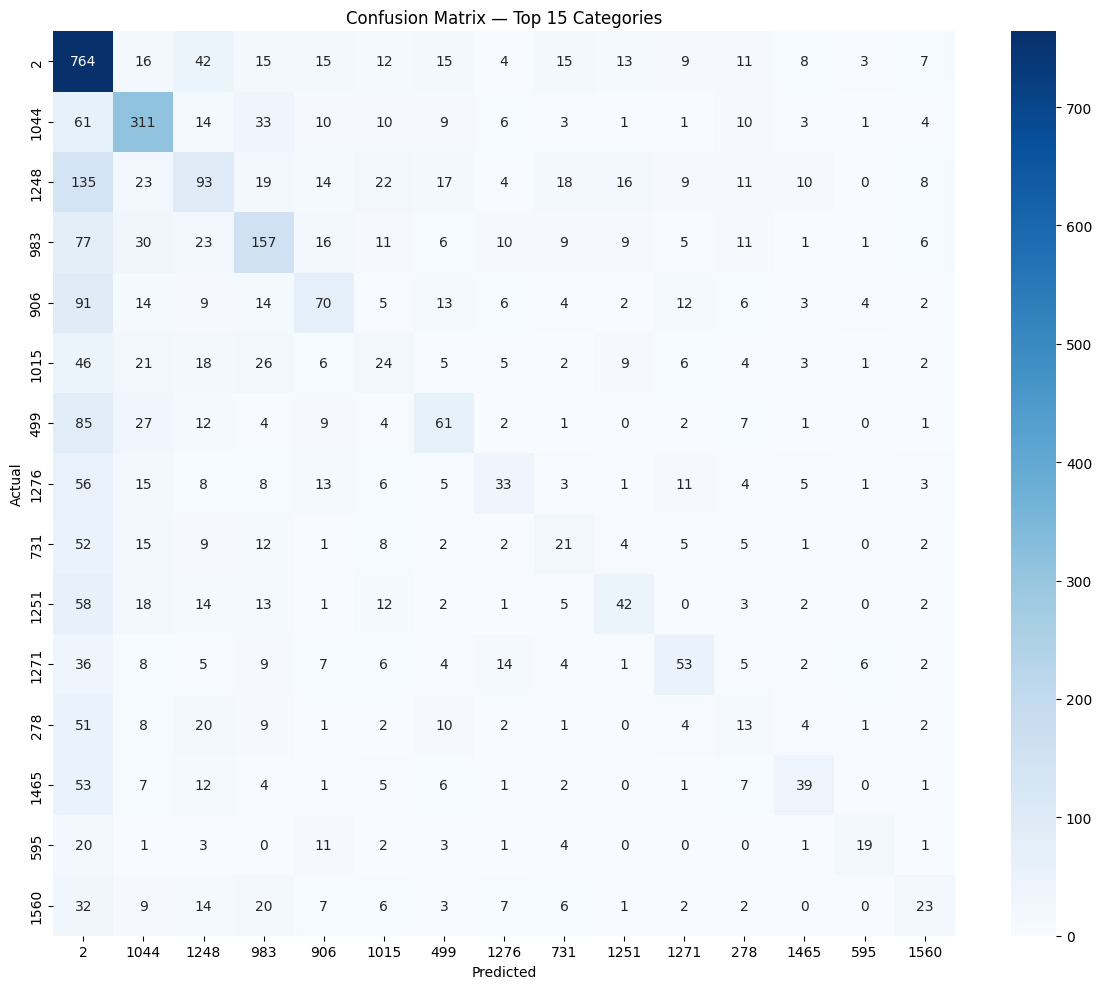

In [19]:
# Confusion matrix for top 15 categories
top_15_cats = y_test.value_counts().head(15).index.tolist()
mask_15 = y_test.isin(top_15_cats)

cm = confusion_matrix(y_test[mask_15], y_pred_tuned[mask_15], labels=top_15_cats)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_15_cats, yticklabels=top_15_cats, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Top 15 Categories')
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Top 20 most frequent categories in test set
top_20_classes = pd.Series(y_test).value_counts().head(20).index.tolist()
n_classes_full = int(y_test.max()) + 1
cm_full = confusion_matrix(y_test, y_pred_tuned, labels=list(range(n_classes_full)))
total = len(y_test)

rows = []
for cls in top_20_classes:
    tp = int(cm_full[cls, cls])
    fp = int(cm_full[:, cls].sum() - tp)
    fn = int(cm_full[cls, :].sum() - tp)
    tn = int(total - tp - fp - fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    try:
        cls_name = le.inverse_transform([cls])[0]
    except Exception:
        cls_name = str(cls)
    rows.append({"Class": cls_name, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                 "Precision": round(prec,4), "Recall": round(rec,4), "F1": round(f1,4)})

metrics_rf = pd.DataFrame(rows).set_index("Class")
print("Per-class TP / TN / FP / FN - Random Forest, Top 20 Most Frequent Categories:")
print(metrics_rf.to_string())
print()
print(f"Overall Accuracy (all classes): {(y_test == y_pred_tuned).mean():.4f}")

from sklearn.metrics import f1_score
print()
print(f"F1 Macro    (unweighted avg over classes): {f1_score(y_test, y_pred_tuned, average='macro',    zero_division=0):.4f}")
print(f"F1 Weighted (weighted by class support):   {f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0):.4f}")
print(f"F1 Micro    (global TP / FP / FN totals):  {f1_score(y_test, y_pred_tuned, average='micro',    zero_division=0):.4f}")


Per-class TP / TN / FP / FN - Random Forest, Top 20 Most Frequent Categories:
        TP     TN    FP   FN  Precision  Recall      F1
Class                                                  
2      764  35591  6023  951     0.1126  0.4455  0.1797
1044   311  41014  1451  553     0.1765  0.3600  0.2369
1248    93  41189  1317  730     0.0660  0.1130  0.0833
983    157  41519  1116  537     0.1233  0.2262  0.1596
906     70  42238   600  421     0.1045  0.1426  0.1206
1015    24  42281   625  399     0.0370  0.0567  0.0448
499     61  41955   953  360     0.0602  0.1449  0.0850
1276    33  42518   392  386     0.0776  0.0788  0.0782
731     21  42521   437  350     0.0459  0.0566  0.0507
1251    42  42343   616  328     0.0638  0.1135  0.0817
1271    53  42540   431  305     0.1095  0.1480  0.1259
278     13  42474   535  307     0.0237  0.0406  0.0300
1465    39  42691   333  266     0.1048  0.1279  0.1152
595     19  42878   162  270     0.1050  0.0657  0.0809
1560    23  42793   251  2

## 6. Cross-Validation

Stratified K-Fold cross-validation on the full training set to estimate model generalization.

In [21]:
%%time

# Filter to categories with enough members for stratified splits
train_df = pd.DataFrame(X_train_sub, columns=feature_names)
train_df['Category'] = y_train_sub.values

cat_counts = train_df['Category'].value_counts()
valid_cats = cat_counts[cat_counts >= 5].index
train_df_filtered = train_df[train_df['Category'].isin(valid_cats)]

X_cv = train_df_filtered.drop('Category', axis=1).values
y_cv = train_df_filtered['Category'].values

print(f'CV data: {len(X_cv):,} samples, {len(valid_cats)} categories (filtered to >= 5 samples per class)')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(
    **best_params,
    n_jobs=-1,
    random_state=42
)

cv_scores = cross_val_score(rf_cv, X_cv, y_cv, cv=cv, scoring=scorer, n_jobs=1)

print(f'\nCV F1 (weighted) scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')

CV data: 113,032 samples, 1317 categories (filtered to >= 5 samples per class)

CV F1 (weighted) scores: [0.14559701 0.1436942  0.14606685 0.14357519 0.14694344]
Mean: 0.1452 (+/- 0.0027)
CPU times: total: 5min 46s
Wall time: 28.6 s


In [22]:
# Also compute CV accuracy
cv_acc_scores = cross_val_score(rf_cv, X_cv, y_cv, cv=cv, scoring='accuracy', n_jobs=1)

print(f'CV Accuracy scores: {cv_acc_scores}')
print(f'Mean: {cv_acc_scores.mean():.4f} (+/- {cv_acc_scores.std() * 2:.4f}')

CV Accuracy scores: [0.17653824 0.17662671 0.17681147 0.17729806 0.17990799]
Mean: 0.1774 (+/- 0.0025


## 7. Summary

In [23]:
print('=' * 55)
print('        RANDOM FOREST — RESULTS SUMMARY')
print('=' * 55)
print(f'  Dataset:              {data.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'  Categories:           {data["Category"].nunique()}')
print(f'  Train size:           {len(y_train_sub):,}')
print(f'  Test set:             {len(y_test):,}')
print(f'')
print(f'  --- Baseline (default RF) ---')
print(f'  Accuracy:             {baseline_acc:.4f}')
print(f'  F1 (weighted):        {baseline_f1_weighted:.4f}')
print(f'')
print(f'  --- Tuned RF ---')
print(f'  Best params:          {best_params}')
print(f'  Accuracy:             {tuned_acc:.4f}')
print(f'  Precision (macro):    {tuned_prec_macro:.4f}')
print(f'  Recall (macro):       {tuned_rec_macro:.4f}')
print(f'  F1 (macro):           {tuned_f1_macro:.4f}')
print(f'  F1 (weighted):        {tuned_f1_weighted:.4f}')
print(f'')
print(f'  --- Cross-Validation (5-fold, full train) ---')
print(f'  F1 (weighted):        {cv_scores.mean():.4f} +/- {cv_scores.std() * 2:.4f}')
print(f'  Accuracy:             {cv_acc_scores.mean():.4f} +/- {cv_acc_scores.std() * 2:.4f}')
print('=' * 55)

        RANDOM FOREST — RESULTS SUMMARY
  Dataset:              157,026 samples, 153 features
  Categories:           1625
  Train size:           113,655
  Test set:             43,329

  --- Baseline (default RF) ---
  Accuracy:             0.0278
  F1 (weighted):        0.0318

  --- Tuned RF ---
  Best params:          {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': None}
  Accuracy:             0.0728
  Precision (macro):    0.0157
  Recall (macro):       0.0138
  F1 (macro):           0.0126
  F1 (weighted):        0.0536

  --- Cross-Validation (5-fold, full train) ---
  F1 (weighted):        0.1452 +/- 0.0027
  Accuracy:             0.1774 +/- 0.0025
